# Two-Step Floating Catchment Area (2SFCA) Accessibility Analysis
## Pharmacy Access in Gauteng and KwaZulu-Natal, South Africa

This notebook computes a **pharmacy accessibility score** for every Small Area Layer (SAL) in Gauteng and KwaZulu-Natal using the Two-Step Floating Catchment
Area (2SFCA) method with network-based routing.

**What the score means:** A higher score indicates better pharmacy access. A score of zero means no registered pharmacy is reachable within the travel distance on the road network.

**How it works (two steps):**
1. **Step 1 (Supply side):** For each pharmacy, travel outward on the road network up to a cutoff distance. Count the decay-weighted population of all neighborhoods within reach. Compute a supply-to-demand ratio (Rj).
2. **Step 2 (Demand side):** For each neighborhood, travel outward on the road network. Sum the supply ratios (Rj) of all reachable pharmacies, weighted by distance decay. The result is the accessibility score (Ai).

**Four runs:** Walk and drive networks for each province, with catchment distances reflecting the different settlement patterns:
- **Gauteng** (dense, urban): 2 km walk / 5 km drive
- **KwaZulu-Natal** (sparse, rural): 3 km walk / 10 km drive

The asymmetric thresholds are intentional. KZN is ~7x larger than Gauteng and much less densely populated. Residents in rural/traditional KZN areas travel longer distances for medicine as a matter of daily life.

## SETUP AND IMPORTS

In [88]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import osmnx as ox
import networkx as nx
from tqdm import tqdm
from shapely.geometry import Point
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [89]:
# Register Space Mono fonts
for f in [
    "data/Space_Mono/SpaceMono-Regular.ttf",
    "data/Space_Mono/SpaceMono-Bold.ttf",
    "data/Space_Mono/SpaceMono-Italic.ttf",
    "data/Space_Mono/SpaceMono-BoldItalic.ttf",
]:
    fm.fontManager.addfont(f)

# Register Space Grotesk fonts
for f in [
    "data/Space_Grotesk/static/SpaceGrotesk-Regular.ttf",
    "data/Space_Grotesk/static/SpaceGrotesk-Medium.ttf",
    "data/Space_Grotesk/static/SpaceGrotesk-Bold.ttf",
    "data/Space_Grotesk/static/SpaceGrotesk-Light.ttf",
    "data/Space_Grotesk/static/SpaceGrotesk-SemiBold.ttf",
]:
    fm.fontManager.addfont(f)

FONT_TITLE  = "Space Mono"    # titles, subtitles, legend titles
FONT_BODY   = "Space Grotesk" # axis labels, tick labels, legend item labels

# Global rcParams — body font as default, override titles manually
plt.rcParams.update({
    "font.family":           FONT_BODY,
    "axes.titlesize":        14,
    "axes.labelsize":        11,
    "xtick.labelsize":       10,
    "ytick.labelsize":       10,
    "legend.fontsize":       10,
    "legend.title_fontsize": 11,
})

print(f"Space Mono available: {'Space Mono' in [f.name for f in fm.fontManager.ttflist]}")
print(f"Space Grotesk available: {'Space Grotesk' in [f.name for f in fm.fontManager.ttflist]}")

Space Mono available: True
Space Grotesk available: True


## LOAD SOURCE DATA

Two main datasets:
- **SAL population estimates** (`pop_pred_final.csv`): ~38,000 Small Area Layers with 2023 population estimates from a dasymetric step-down model.
- **Pharmacy locations** (`PHARMACIES_MASTER_FINAL.csv`): Deduplicated and geocoded pharmacy dataset combining multiple insurer sources.

In [90]:
# Load population and pharmacy data.
sal_raw = pd.read_csv("data/pop_pred_final.csv")
pharmacy_raw = pd.read_csv("data/PHARMACIES_MASTER_FINAL.csv")

# Load SAL geographic boundaries (polygons and centroids).
sal_centroids = gpd.read_file("data/2011_census/2011_ea_sal_centroids_kzn_gp/2011_ea_sal_centroids_kzn_gp.dbf")
sal_polygons = gpd.read_file("data/2011_census/2011_census/ea_sal_kzn_gp.dbf")

pd.reset_option("display.float_format")

## PREPARE PHARMACY AND SAL GEODATAFRAMES

Convert pharmacy coordinates into a spatial GeoDataFrame, merge SAL population data with boundaries, and filter out SALs with population below 100 (uninhabited areas like farms and nature reserves).

In [91]:
# Convert pharmacy table to a spatial GeoDataFrame.
pharmacy_gdf = gpd.GeoDataFrame(
    pharmacy_raw,
    geometry = gpd.points_from_xy(pharmacy_raw["LNG"], pharmacy_raw["LAT"]),
    crs = "EPSG:4326"
)
pharmacy_gdf = pharmacy_gdf.to_crs(sal_polygons.crs)

# Normalize EA_CODE to int64 on both sides to avoid int/float merge warning.
sal_raw["EA_CODE"] = pd.to_numeric(sal_raw["EA_CODE"], errors = "coerce").astype("int64")
sal_polygons["EA_CODE"] = pd.to_numeric(sal_polygons["EA_CODE"], errors = "coerce").astype("int64")

# Merge SAL population data with polygon geometries.
sal = sal_raw.merge(
    sal_polygons[["EA_CODE", "PR_NAME", "geometry"]],
    on = "EA_CODE",
    how = "left"
)
sal = gpd.GeoDataFrame(sal, geometry = "geometry")

# Filter out SALs with population below 100.
sal = sal[sal["sal2023_est"] >= 100].copy()
print(f"SALs AFTER POPULATION FILTER: {len(sal)}")

SALs AFTER POPULATION FILTER: 37663


## VARIABLE CATCHMENT (OPTIONAL, COMMENTED OUT)

An alternative to fixed per-province catchment distances is to assign catchments based on each SAL's settlement type (Urban, Traditional, Other). Something to strongly consider, but need to take a closer look at the settlement types and their distribution across the two provinces before implementing.

**If enabled:** replace the hardcoded `cutoff` values in each 2SFCA call with per-SAL catchment distances. The 2SFCA loop structure would need modification to read each SAL's individual catchment.

In [53]:
# VARIABLE_CATCHMENT = True

# def assign_catchment(row):
#     """Assign catchment distance (meters) based on settlement type."""
#     if row["EA_GTYPE"] == "Urban":
#         return 2000
#     elif row["EA_GTYPE"] == "Traditional":
#         return 10000
#     else:
#         return 15000

# sal["catchment"] = sal.apply(assign_catchment, axis = 1)
# print(f"CATCHMENT DISTRIBUTION")
# print(sal.groupby("EA_GTYPE")["catchment"].first())

## SPLIT BY PROVINCE AND ASSIGN PHARMACIES

In [92]:
# Split SALs by province.
kzn_sal = sal[sal["PR_NAME"] == "KwaZulu-Natal"].copy()
gau_sal = sal[sal["PR_NAME"] == "Gauteng"].copy()

# Spatial join: identify pharmacies within each province.
kzn_pharmacies = gpd.sjoin(pharmacy_gdf, kzn_sal, predicate = "within")
gau_pharmacies = gpd.sjoin(pharmacy_gdf, gau_sal, predicate = "within")

print(f"KZN SALs: {len(kzn_sal)}  |  KZN Pharmacies: {len(kzn_pharmacies)}")
print(f"GAU SALs: {len(gau_sal)}  |  GAU Pharmacies: {len(gau_pharmacies)}")

KZN SALs: 16215  |  KZN Pharmacies: 646
GAU SALs: 19492  |  GAU Pharmacies: 1351


## PREVIEW: SAL BOUNDARIES WITH PHARMACY LOCATIONS

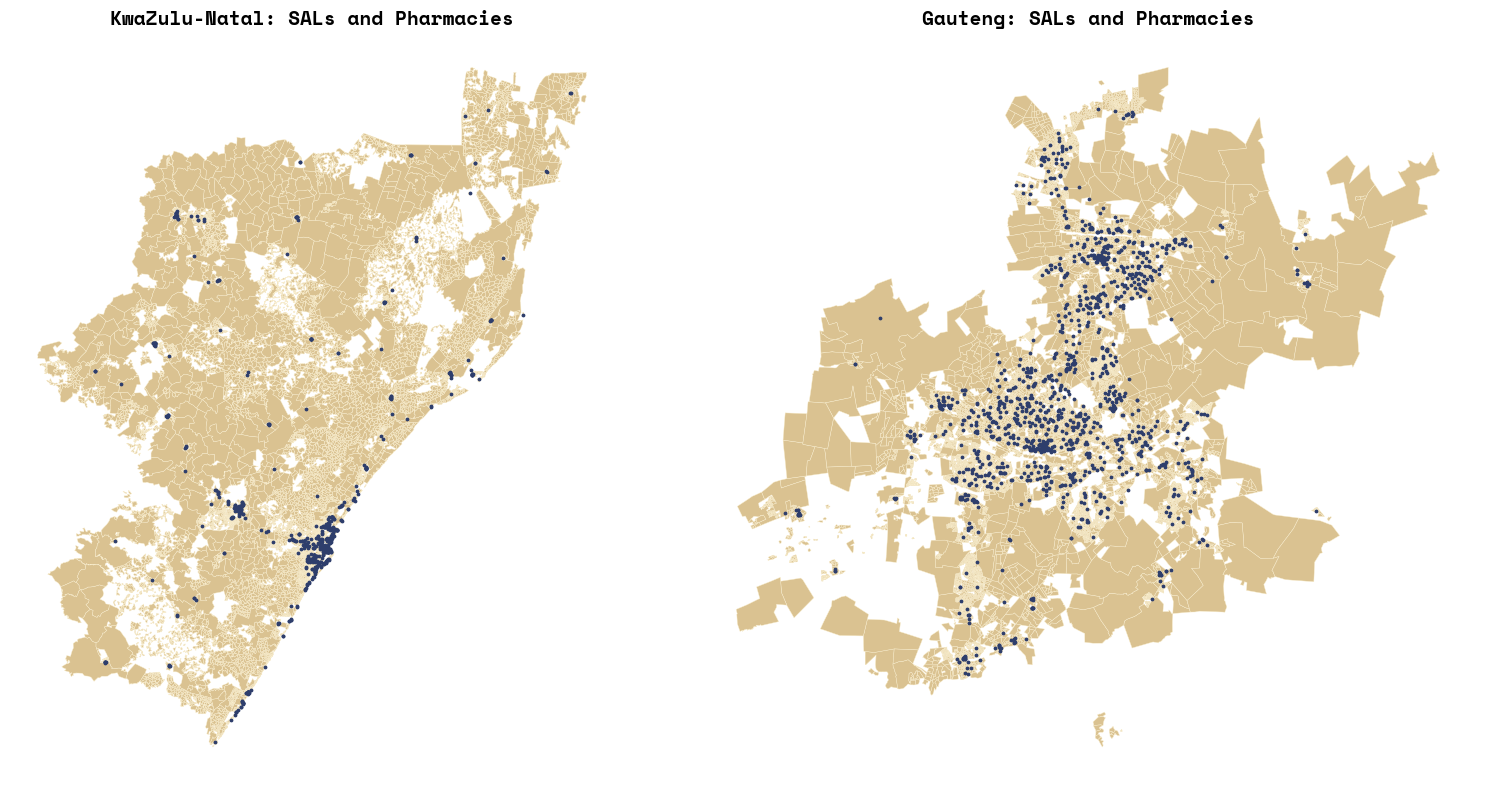

In [96]:
fig, axes = plt.subplots(1, 2, figsize = (16, 8))
fig.patch.set_alpha(0.0)

kzn_sal.plot(ax = axes[0], color = "#dac291", edgecolor = "#f9eece", linewidth = 0.3)
kzn_pharmacies.plot(ax = axes[0], color = "#2e3e6c", markersize = 3, alpha = 1)
axes[0].set_title("KwaZulu-Natal: SALs and Pharmacies", fontfamily = FONT_TITLE, fontweight = "bold")
axes[0].set_facecolor("none")
axes[0].axis("off")

gau_sal.plot(ax = axes[1], color = "#dac291", edgecolor = "#f9eece", linewidth = 0.3)
gau_pharmacies.plot(ax = axes[1], color = "#2e3e6c", markersize = 3, alpha = 1)
axes[1].set_title("Gauteng: SALs and Pharmacies", fontfamily = FONT_TITLE, fontweight = "bold")
axes[1].set_facecolor("none")
axes[1].axis("off")

plt.tight_layout()
fig.patch.set_alpha(0.0)
fig.savefig("images/2sfca_province_preview.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

## DISTANCE DECAY FUNCTION

**Previous version used beta = 0.0001**, which produced almost no decay, so a pharmacy 10 km away still received 37% weight, and essentially the model could barely
distinguish near from far.

**Updated to beta = 0.0003** for meaningful distance discrimination:

| Distance | Weight |
|----------|--------|
| 0 m      | 1.000  |
| 1 km     | 0.741  |
| 2 km     | 0.549  |
| 3 km     | 0.407  |
| 5 km     | 0.223  |
| 10 km    | 0.050  |

In [56]:
def decay(distance, beta = 0.0003):
    """Negative exponential distance decay function."""
    return np.exp(-beta * distance)

## 2SFCA COMPUTATION FUNCTION

Contains two bug fixes from the previous version:

**Fix 1 - Node collision:** The old code used `.set_index("node")` to build the population lookup, so when multiple SALs snapped to the same road node, only one SAL's population was kept. The fix uses `.groupby("node").sum()` to add all populations together.

**Fix 2 - Rj outlier cap:** A pharmacy with only 3 people in its catchment produced Rj = 1000/3 = 333, creating scores 5,000x the mean. A minimum population floor of 50 prevents these runaway ratios.

In [ ]:
MIN_WEIGHTED_POP = 50

def run_2sfca(sal_gdf, pharm_gdf, graph, cutoff_meters, score_column):
    """Run both steps of the 2SFCA for one province/mode combination.

    Parameters
    ----------
    sal_gdf : GeoDataFrame with "node" and "sal2023_est" columns.
    pharm_gdf : GeoDataFrame with "node" column.
    graph : Projected OSMnx road network.
    cutoff_meters : Maximum network travel distance for catchment.
    score_column : Name of the output column (e.g. "Ai_walk").
    """
    # FIX 1: groupby-sum handles node collisions (old code used set_index
    # which silently dropped populations when SALs shared a network node).
    pop_dict = sal_gdf.groupby("node")["sal2023_est"].sum().to_dict()

    # STEP 1: Calculate supply-to-demand ratio (Rj) for each pharmacy.
    print(f"STEP 1: Computing Rj for {len(pharm_gdf)} pharmacies (cutoff = {cutoff_meters}m)")
    rj_list = []

    for idx, pharm in tqdm(pharm_gdf.iterrows(), total = len(pharm_gdf)):
        # Dijkstra traversal outward from this pharmacy.
        lengths = nx.single_source_dijkstra_path_length(
            graph, pharm["node"], cutoff = cutoff_meters, weight = "length"
        )

        # Sum decay-weighted population of all reachable SALs.
        weighted_pop = sum(
            pop_dict.get(node, 0) * decay(dist)
            for node, dist in lengths.items()
        )

        # FIX 2: Floor prevents near-infinite Rj from sparse catchments.
        if weighted_pop > 0:
            rj = 1 / (max(weighted_pop, MIN_WEIGHTED_POP) / 1000)
        else:
            rj = 0
        rj_list.append(rj)

    pharm_gdf["Rj"] = rj_list
    pharm_dict = pharm_gdf.groupby("node")["Rj"].sum().to_dict()

    # STEP 2: Calculate accessibility score (Ai) for each SAL.
    print(f"STEP 2: Computing Ai for {len(sal_gdf)} SALs")
    ai_list = []

    for idx, pop in tqdm(sal_gdf.iterrows(), total = len(sal_gdf)):
        lengths = nx.single_source_dijkstra_path_length(
            graph, pop["node"], cutoff = cutoff_meters, weight = "length"
        )
        ai = sum(
            pharm_dict.get(node, 0) * decay(dist)
            for node, dist in lengths.items()
        )
        ai_list.append(ai)

    sal_gdf[score_column] = ai_list
    print(f"COMPLETE: {score_column}")
    print(sal_gdf[score_column].describe())
    return sal_gdf

## KWAZULU-NATAL: WALKING ACCESSIBILITY (3 km catchment)

Graph loading is slow. The raw graph is loaded once into a static variable.
All transformations (projection) are saved into separate variables.

In [58]:
# Load raw graph once (SLOW AF STEP - PLEAK DO NOT RE-RUN `load_graphml` CELLS UNNECESSARILY).
kzn_walk_graph_raw = ox.load_graphml("data/networks/network_kwazulu_natal_walk.graphml")
print(f"KZN walk RAW: {kzn_walk_graph_raw.number_of_nodes()} nodes, {kzn_walk_graph_raw.number_of_edges()} edges")

KZN walk RAW: 541204 nodes, 1356318 edges


In [59]:
# Project into a working copy.
kzn_walk_graph = ox.project_graph(kzn_walk_graph_raw, to_crs = "EPSG:32735")
print(f"KZN walk PROJECTED: {kzn_walk_graph.number_of_nodes()} nodes, {kzn_walk_graph.number_of_edges()} edges")

kzn_sal = kzn_sal.to_crs(kzn_walk_graph.graph["crs"])
kzn_sal = kzn_sal.set_geometry(kzn_sal.geometry.centroid)
kzn_pharmacies = kzn_pharmacies.to_crs(kzn_walk_graph.graph["crs"])

kzn_sal["node"] = ox.nearest_nodes(kzn_walk_graph, kzn_sal.geometry.x, kzn_sal.geometry.y)
kzn_walk_pharm = kzn_pharmacies.copy()
kzn_walk_pharm["node"] = ox.nearest_nodes(kzn_walk_graph, kzn_walk_pharm.geometry.x, kzn_walk_pharm.geometry.y)

KZN walk PROJECTED: 541204 nodes, 1356318 edges


In [60]:
kzn_sal = run_2sfca(kzn_sal, kzn_walk_pharm, kzn_walk_graph, cutoff_meters = 3000, score_column = "Ai_walk")

STEP 1: Computing Rj for 646 pharmacies (cutoff = 3000m)


100%|██████████| 646/646 [00:08<00:00, 75.35it/s] 


STEP 2: Computing Ai for 16215 SALs


100%|██████████| 16215/16215 [01:31<00:00, 176.59it/s]

COMPLETE: Ai_walk
count    16215.000000
mean         0.077798
std          0.258630
min          0.000000
25%          0.000000
50%          0.000000
75%          0.048280
max         22.278115
Name: Ai_walk, dtype: float64


In [61]:
kzn_sal["Ai_walk"].describe(percentiles = [0.9, 0.95, 0.98, 0.99, 0.999])

count    16215.000000
mean         0.077798
std          0.258630
min          0.000000
90%          0.242617
95%          0.453522
98%          0.702133
99%          0.894953
99.9%        2.070214
max         22.278115
Name: Ai_walk, dtype: float64

## KWAZULU-NATAL: DRIVING ACCESSIBILITY (10 km catchment)

In [62]:
kzn_drive_graph_raw = ox.load_graphml("data/networks/network_kwazulu_natal_drive.graphml")
print(f"KZN drive RAW: {kzn_drive_graph_raw.number_of_nodes()} nodes, {kzn_drive_graph_raw.number_of_edges()} edges")

KZN drive RAW: 311426 nodes, 749194 edges


In [63]:
kzn_drive_graph = ox.project_graph(kzn_drive_graph_raw, to_crs = "EPSG:32735")
print(f"KZN drive PROJECTED: {kzn_drive_graph.number_of_nodes()} nodes, {kzn_drive_graph.number_of_edges()} edges")

kzn_sal = kzn_sal.to_crs(kzn_drive_graph.graph["crs"])
kzn_pharmacies = kzn_pharmacies.to_crs(kzn_drive_graph.graph["crs"])

kzn_sal["node"] = ox.nearest_nodes(kzn_drive_graph, kzn_sal.geometry.x, kzn_sal.geometry.y)
kzn_drive_pharm = kzn_pharmacies.copy()
kzn_drive_pharm["node"] = ox.nearest_nodes(kzn_drive_graph, kzn_drive_pharm.geometry.x, kzn_drive_pharm.geometry.y)

KZN drive PROJECTED: 311426 nodes, 749194 edges


In [64]:
kzn_sal = run_2sfca(kzn_sal, kzn_drive_pharm, kzn_drive_graph, cutoff_meters = 10000, score_column = "Ai_drive")

STEP 1: Computing Rj for 646 pharmacies (cutoff = 10000m)


  0%|          | 0/646 [00:00<?, ?it/s]

100%|██████████| 646/646 [00:27<00:00, 23.09it/s]


STEP 2: Computing Ai for 16215 SALs


100%|██████████| 16215/16215 [07:03<00:00, 38.26it/s] 

COMPLETE: Ai_drive
count    16215.000000
mean         0.064098
std          0.113607
min          0.000000
25%          0.000000
50%          0.016423
75%          0.089328
max          4.510463
Name: Ai_drive, dtype: float64


In [65]:
kzn_sal["Ai_drive"].describe(percentiles = [0.9, 0.95, 0.98, 0.99, 0.999])

count    16215.000000
mean         0.064098
std          0.113607
min          0.000000
90%          0.189340
95%          0.283120
98%          0.374903
99%          0.435770
99.9%        0.891700
max          4.510463
Name: Ai_drive, dtype: float64

## GAUTENG: WALKING ACCESSIBILITY (2 km catchment)

In [66]:
gau_walk_graph_raw = ox.load_graphml("data/networks/network_gauteng_walk.graphml")
print(f"GAU walk RAW: {gau_walk_graph_raw.number_of_nodes()} nodes, {gau_walk_graph_raw.number_of_edges()} edges")

GAU walk RAW: 443832 nodes, 1219312 edges


In [67]:
gau_walk_graph = ox.project_graph(gau_walk_graph_raw, to_crs = "EPSG:32735")
print(f"GAU walk PROJECTED: {gau_walk_graph.number_of_nodes()} nodes, {gau_walk_graph.number_of_edges()} edges")

gau_sal = gau_sal.to_crs(gau_walk_graph.graph["crs"])
gau_sal = gau_sal.set_geometry(gau_sal.geometry.centroid)
gau_pharmacies = gau_pharmacies.to_crs(gau_walk_graph.graph["crs"])

gau_sal["node"] = ox.nearest_nodes(gau_walk_graph, gau_sal.geometry.x, gau_sal.geometry.y)
gau_walk_pharm = gau_pharmacies.copy()
gau_walk_pharm["node"] = ox.nearest_nodes(gau_walk_graph, gau_walk_pharm.geometry.x, gau_walk_pharm.geometry.y)

GAU walk PROJECTED: 443832 nodes, 1219312 edges


In [68]:
gau_sal = run_2sfca(gau_sal, gau_walk_pharm, gau_walk_graph, cutoff_meters = 2000, score_column = "Ai_walk")

STEP 1: Computing Rj for 1351 pharmacies (cutoff = 2000m)


100%|██████████| 1351/1351 [00:10<00:00, 131.61it/s]


STEP 2: Computing Ai for 19492 SALs


100%|██████████| 19492/19492 [01:37<00:00, 200.12it/s]

COMPLETE: Ai_walk
count    19492.000000
mean         0.147502
std          0.274501
min          0.000000
25%          0.000000
50%          0.037113
75%          0.174184
max          5.886520
Name: Ai_walk, dtype: float64


In [69]:
gau_sal["Ai_walk"].describe(percentiles = [0.9, 0.95, 0.98, 0.99, 0.999])

count    19492.000000
mean         0.147502
std          0.274501
min          0.000000
90%          0.446149
95%          0.649459
98%          0.949735
99%          1.199376
99.9%        2.651421
max          5.886520
Name: Ai_walk, dtype: float64

## GAUTENG: DRIVING ACCESSIBILITY (5 km catchment)

In [70]:
gau_drive_graph_raw = ox.load_graphml("data/networks/network_gauteng_drive.graphml")
print(f"GAU drive RAW: {gau_drive_graph_raw.number_of_nodes()} nodes, {gau_drive_graph_raw.number_of_edges()} edges")

GAU drive RAW: 279004 nodes, 730792 edges


In [71]:
gau_drive_graph = ox.project_graph(gau_drive_graph_raw)
print(f"GAU drive PROJECTED: {gau_drive_graph.number_of_nodes()} nodes, {gau_drive_graph.number_of_edges()} edges")

gau_sal = gau_sal.to_crs(gau_drive_graph.graph["crs"])
gau_pharmacies = gau_pharmacies.to_crs(gau_drive_graph.graph["crs"])

gau_sal["node"] = ox.nearest_nodes(gau_drive_graph, gau_sal.geometry.x, gau_sal.geometry.y)
gau_drive_pharm = gau_pharmacies.copy()
gau_drive_pharm["node"] = ox.nearest_nodes(gau_drive_graph, gau_drive_pharm.geometry.x, gau_drive_pharm.geometry.y)

GAU drive PROJECTED: 279004 nodes, 730792 edges


In [72]:
gau_sal = run_2sfca(gau_sal, gau_drive_pharm, gau_drive_graph, cutoff_meters = 5000, score_column = "Ai_drive")

STEP 1: Computing Rj for 1351 pharmacies (cutoff = 5000m)


100%|██████████| 1351/1351 [00:26<00:00, 51.48it/s]


STEP 2: Computing Ai for 19492 SALs


100%|██████████| 19492/19492 [06:07<00:00, 53.05it/s] 

COMPLETE: Ai_drive
count    19492.000000
mean         0.178793
std          0.395099
min          0.000000
25%          0.019666
50%          0.051675
75%          0.225899
max          8.841993
Name: Ai_drive, dtype: float64


In [73]:
gau_sal["Ai_drive"].describe(percentiles = [0.9, 0.95, 0.98, 0.99, 0.999])

count    19492.000000
mean         0.178793
std          0.395099
min          0.000000
90%          0.397489
95%          0.557451
98%          1.100442
99%          2.056544
99.9%        4.385767
max          8.841993
Name: Ai_drive, dtype: float64

## SCORE DISTRIBUTION HISTOGRAMS

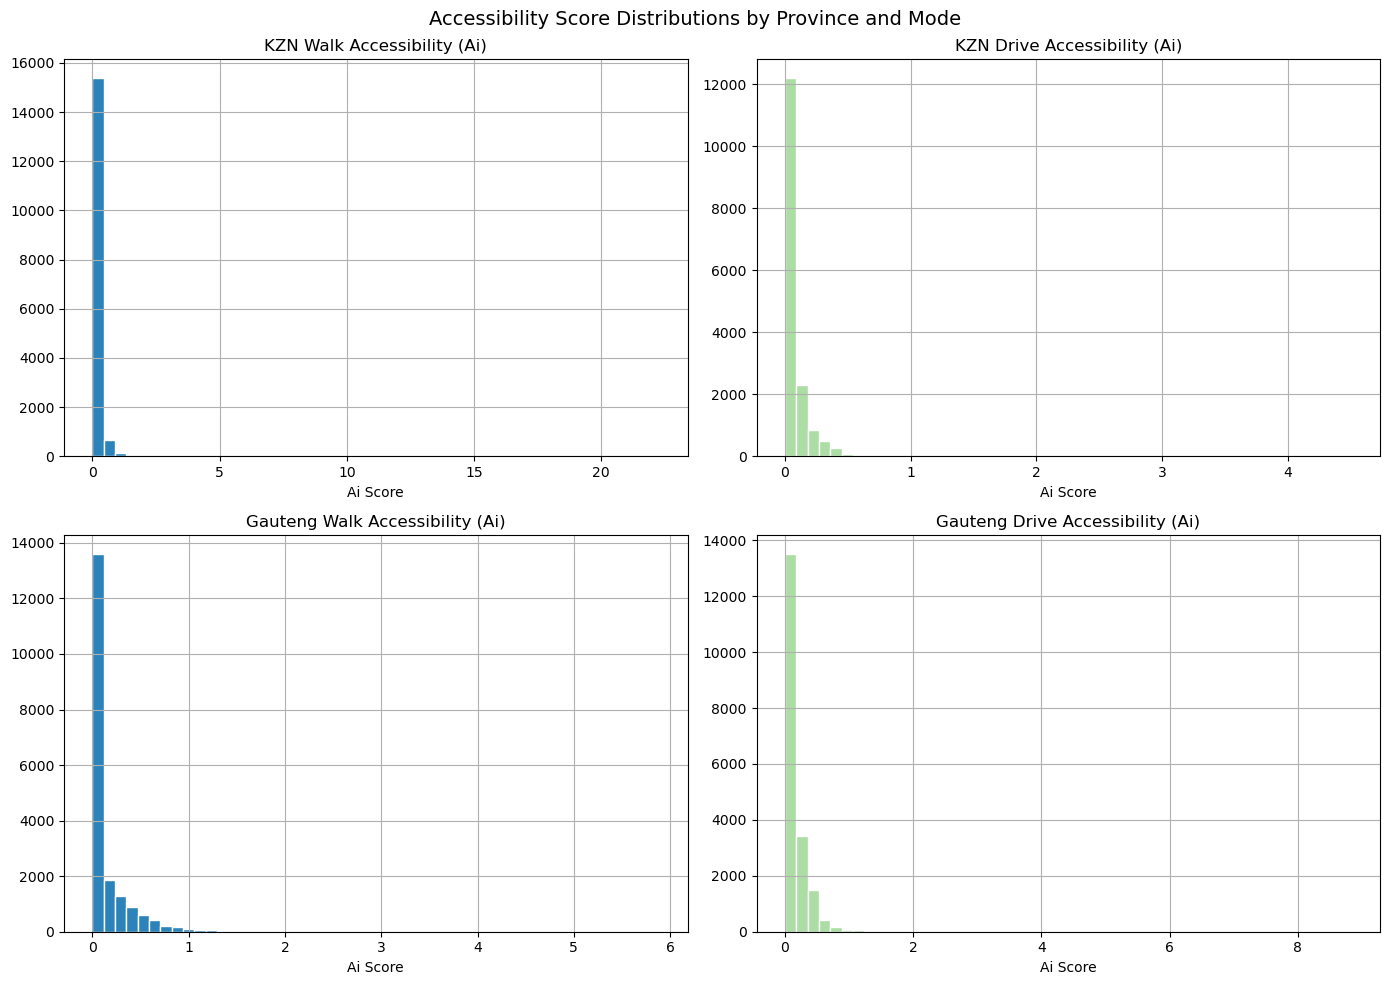

In [74]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))

kzn_sal["Ai_walk"].hist(ax = axes[0, 0], bins = 50, color = "#2b83ba", edgecolor = "white")
axes[0, 0].set_title("KZN Walk Accessibility (Ai)")
axes[0, 0].set_xlabel("Ai Score")

kzn_sal["Ai_drive"].hist(ax = axes[0, 1], bins = 50, color = "#abdda4", edgecolor = "white")
axes[0, 1].set_title("KZN Drive Accessibility (Ai)")
axes[0, 1].set_xlabel("Ai Score")

gau_sal["Ai_walk"].hist(ax = axes[1, 0], bins = 50, color = "#2b83ba", edgecolor = "white")
axes[1, 0].set_title("Gauteng Walk Accessibility (Ai)")
axes[1, 0].set_xlabel("Ai Score")

gau_sal["Ai_drive"].hist(ax = axes[1, 1], bins = 50, color = "#abdda4", edgecolor = "white")
axes[1, 1].set_title("Gauteng Drive Accessibility (Ai)")
axes[1, 1].set_xlabel("Ai Score")

plt.suptitle("Accessibility Score Distributions by Province and Mode", fontsize = 14)
plt.tight_layout()
plt.show()

## COMBINE PROVINCES AND EXPORT

In [75]:
# Compute percentile ranks within each province.
for province_sal in [kzn_sal, gau_sal]:
    for col in ["Ai_walk", "Ai_drive"]:
        rank_col = col.replace("Ai_", "") + "_rank"
        province_sal[rank_col] = 0.0
        nonzero = province_sal[col] > 0
        province_sal.loc[nonzero, rank_col] = province_sal.loc[nonzero, col].rank(pct = True)

# Log-transform scores for mapping.
for province_sal in [kzn_sal, gau_sal]:
    province_sal["walk_log"] = np.log1p(province_sal["Ai_walk"])
    province_sal["drive_log"] = np.log1p(province_sal["Ai_drive"])

# Combine both provinces.
allaccess = pd.concat([kzn_sal, gau_sal], ignore_index = True)
allaccess = allaccess.drop(columns = "geometry")

# Merge back with SAL polygons for mapping.
allaccess = sal_polygons.merge(allaccess, on = "EA_CODE", how = "left")

# Fill NaN scores with 0.
score_cols = ["walk_log", "drive_log", "walk_rank", "drive_rank"]
allaccess[score_cols] = allaccess[score_cols].fillna(0)
for c in score_cols:
    allaccess[c] = pd.to_numeric(allaccess[c], errors = "coerce")

# Clean up duplicate columns from merges.
x_cols = [c for c in allaccess.columns if c.endswith("_x")]
y_cols = [c for c in allaccess.columns if c.endswith("_y")]
allaccess = allaccess.drop(columns = y_cols)
allaccess = allaccess.rename(columns = {c: c[:-2] for c in x_cols})

print(f"COMBINED DATASET: {len(allaccess)} SALs")

COMBINED DATASET: 44631 SALs


In [76]:
# Export to CSV.
# Convert to plain DataFrame first so assigning WKT strings to "geometry"
# doesn't trigger the "Geometry column does not contain geometry" warning.
allaccess_export = pd.DataFrame(allaccess.copy())
allaccess_export["geometry"] = allaccess.geometry.to_wkt()
allaccess_export.to_csv(
    "data/tess_all_access.csv",
    index = False,
    float_format = "%.6f",
    na_rep = ""
)
print("EXPORTED: data/tess_all_access.csv")

EXPORTED: data/tess_all_access.csv


## CATEGORICAL ACCESSIBILITY CLASSIFICATION

Assigns each SAL to a policy-relevant tier. Tiers are computed **within each province** because the catchment thresholds are intentionally asymmetric. The **Formal Desert** tier (Ai = 0) flags SALs where no registered pharmacy is reachable, and whether medication access exists through gray market or informal channels cannot be determined from the formal data.

| Tier | Definition | Policy Implication |
|------|-----------|-------------------|
| **Formal Desert** | Ai = 0 | No pharmacy reachable. NHI needs new infrastructure. |
| **Pharmacy Desert** | Bottom third of non-zero scores | Priority for NHI accreditation. |
| **Average Access** | Middle third | Baseline formal-sector access. |
| **Served** | Upper third | Adequate formal access. |
| **Overserved** | Top 5% | Very high access, and an equity concern if correlated with wealth. |

In [77]:
def classify_access(df, score_col, tier_col):
    """Classify SALs into accessibility tiers within a single province."""
    df[tier_col] = "Formal Desert"
    nonzero_mask = df[score_col] > 0
    nonzero_scores = df.loc[nonzero_mask, score_col]

    if len(nonzero_scores) == 0:
        return df

    t33 = nonzero_scores.quantile(0.333)
    t66 = nonzero_scores.quantile(0.666)
    t95 = nonzero_scores.quantile(0.95)

    df.loc[nonzero_mask & (df[score_col] <= t33), tier_col] = "Pharmacy Desert"
    df.loc[nonzero_mask & (df[score_col] > t33) & (df[score_col] <= t66), tier_col] = "Average Access"
    df.loc[nonzero_mask & (df[score_col] > t66) & (df[score_col] <= t95), tier_col] = "Served"
    df.loc[nonzero_mask & (df[score_col] > t95), tier_col] = "Overserved"
    return df

# Initialize columns BEFORE the loop so .loc can write into them.
allaccess["walk_tier"] = "Formal Desert"
allaccess["drive_tier"] = "Formal Desert"

for prov in allaccess["PR_NAME"].dropna().unique():
    prov_mask = allaccess["PR_NAME"] == prov

    classified = classify_access(allaccess.loc[prov_mask].copy(), "Ai_walk", "walk_tier")
    allaccess.loc[prov_mask, "walk_tier"] = classified["walk_tier"].values

    classified = classify_access(allaccess.loc[prov_mask].copy(), "Ai_drive", "drive_tier")
    allaccess.loc[prov_mask, "drive_tier"] = classified["drive_tier"].values

tier_order = ["Formal Desert", "Pharmacy Desert", "Average Access", "Served", "Overserved"]
allaccess["walk_tier"] = pd.Categorical(allaccess["walk_tier"], categories = tier_order, ordered = True)
allaccess["drive_tier"] = pd.Categorical(allaccess["drive_tier"], categories = tier_order, ordered = True)

print("WALK TIER COUNTS BY PROVINCE")
print(allaccess.groupby("PR_NAME")["walk_tier"].value_counts().unstack(fill_value = 0))
print()
print("DRIVE TIER COUNTS BY PROVINCE")
print(allaccess.groupby("PR_NAME")["drive_tier"].value_counts().unstack(fill_value = 0))

WALK TIER COUNTS BY PROVINCE
walk_tier      Formal Desert  Pharmacy Desert  Average Access  Served  \
PR_NAME                                                                 
Gauteng                 8210             5269            5266    4492   
KwaZulu-Natal          13361             2412            2411    2056   

walk_tier      Overserved  
PR_NAME                    
Gauteng               791  
KwaZulu-Natal         363  

DRIVE TIER COUNTS BY PROVINCE
drive_tier     Formal Desert  Pharmacy Desert  Average Access  Served  \
PR_NAME                                                                 
Gauteng                 3311             6899            6898    5884   
KwaZulu-Natal           8758             3945            3944    3363   

drive_tier     Overserved  
PR_NAME                    
Gauteng              1036  
KwaZulu-Natal         593  


In [78]:
print("WALK TIER PERCENTAGES BY PROVINCE")
walk_pct = allaccess.groupby("PR_NAME")["walk_tier"].value_counts(normalize = True).unstack(fill_value = 0)
print((walk_pct * 100).round(1))
print()
print("DRIVE TIER PERCENTAGES BY PROVINCE")
drive_pct = allaccess.groupby("PR_NAME")["drive_tier"].value_counts(normalize = True).unstack(fill_value = 0)
print((drive_pct * 100).round(1))

WALK TIER PERCENTAGES BY PROVINCE
walk_tier      Formal Desert  Pharmacy Desert  Average Access  Served  \
PR_NAME                                                                 
Gauteng                 34.2             21.9            21.9    18.7   
KwaZulu-Natal           64.8             11.7            11.7    10.0   

walk_tier      Overserved  
PR_NAME                    
Gauteng               3.3  
KwaZulu-Natal         1.8  

DRIVE TIER PERCENTAGES BY PROVINCE
drive_tier     Formal Desert  Pharmacy Desert  Average Access  Served  \
PR_NAME                                                                 
Gauteng                 13.8             28.7            28.7    24.5   
KwaZulu-Natal           42.5             19.1            19.1    16.3   

drive_tier     Overserved  
PR_NAME                    
Gauteng               4.3  
KwaZulu-Natal         2.9  


## NOTE: TRANSIT ACCESSIBILITY (LOOKING INTO THIS)

The walk and drive networks miss the dominant transport mode for most South Africans, which is the minibus taxi system. A SAL classified as a Formal Desert on walking may actually be served by a taxi route passing through a commercial center with a pharmacy.

Incorporating transit via GTFS data would add a third modal layer, and potential sources could be formal BRT/rail GTFS feeds (Rea Vaya, Gautrain), crowdsourced GPS traces (WhereIsMyTransport, Digital Matatus methodology), and OpenStreetMap transit relations. Currently looking into, but probably will go into a future work section tbh.

## NOTE: NHI READINESS INDEX (FUTURE PROBABLY)

The 2SFCA score measures one dimension of access. A comprehensive **NHI Readiness Index** would integrate:
- **Spatial accessibility** (2SFCA scores from this notebook)
- **Demographic vulnerability** (age structure, chronic disease proxies)
- **Provider capacity** (pharmacist counts, hours, inventory depth, although I believe only hours data is available)
- **Transit accessibility** (see my GTFS note above)
- **Historical deprivation** (EA_TYPE and econ_status, encoding apartheid-era settlement patterns that persist as structural barriers)

This is a future direction, but it would be nice if we could've done it for this project. :/

## MAPS AND VISUALIZATIONS

In [97]:
# Reload from CSV for mapping (ensures clean state).
allaccess = pd.read_csv("data/tess_all_access.csv", low_memory = False)
allaccess["EA_CODE"] = pd.to_numeric(allaccess["EA_CODE"], errors = "coerce").astype("int64")

# Reproject SAL polygons to Web Mercator for display.
sal_polygons_3857 = sal_polygons.to_crs(epsg = 3857)

allaccess = allaccess.drop(columns = ["geometry"], errors = "ignore").merge(
    sal_polygons_3857[["EA_CODE", "geometry"]],
    on = "EA_CODE",
    how = "left"
)
allaccess = gpd.GeoDataFrame(allaccess, geometry = "geometry", crs = sal_polygons_3857.crs)

# Pharmacy overlay in matching CRS.
pharm_with_sal = pharmacy_gdf.to_crs(allaccess.crs)

print(f"MAP DATA READY: {len(allaccess)} SALs")

MAP DATA READY: 56753 SALs


### Johannesburg Walking Accessibility

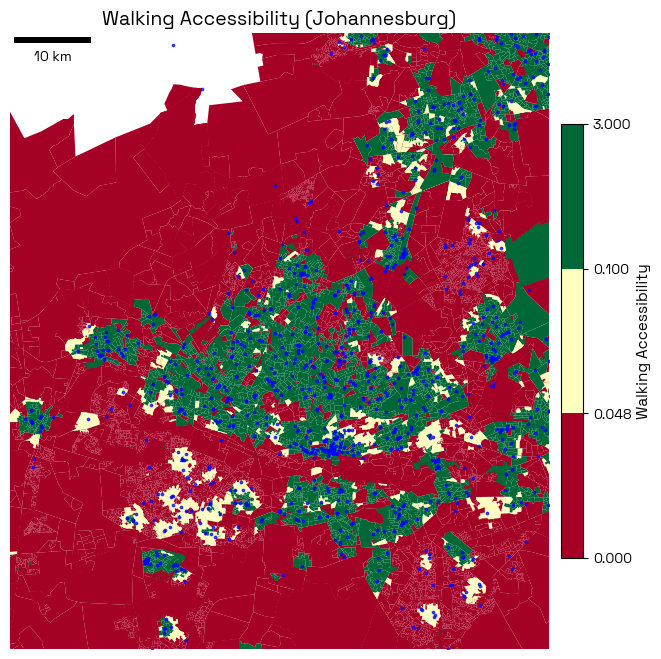

In [98]:
bin_edges = [0, 0.048, 0.1, 3]
cmap = mpl.colormaps["RdYlGn"].resampled(3)
norm = mpl.colors.BoundaryNorm(bin_edges, ncolors = cmap.N)

fig, ax = plt.subplots(figsize = (8, 8))
allaccess.plot(column = "walk_log", cmap = cmap, scheme = "UserDefined",
               classification_kwds = {"bins": bin_edges}, ax = ax, edgecolor = "none")
pharm_with_sal.plot(ax = ax, color = "blue", markersize = 3, alpha = 0.7)

ax.set_xlim(3080000, 3150000)
ax.set_ylim(-3050000, -2970000)

scalebar = ScaleBar(dx = 1, units = "m", dimension = "si-length", location = "upper left")
ax.add_artist(scalebar)
sm = mpl.cm.ScalarMappable(cmap = cmap, norm = norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax = ax, fraction = 0.035, pad = 0.02)
cbar.set_label("Walking Accessibility")
ax.set_title("Walking Accessibility (Johannesburg)")
ax.axis("off")
plt.show()

### Durban Walking Accessibility

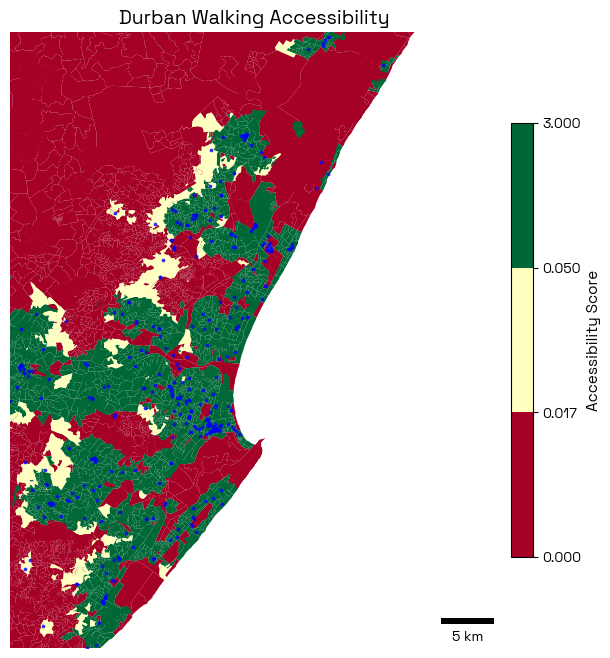

In [99]:
bin_edges = [0, 0.017, 0.05, 3]
cmap = mpl.colormaps["RdYlGn"].resampled(3)
norm = mpl.colors.BoundaryNorm(bin_edges, ncolors = cmap.N)

fig, ax = plt.subplots(figsize = (8, 8))
allaccess.plot(column = "walk_log", cmap = cmap, norm = norm, edgecolor = "none", ax = ax)
pharm_with_sal.plot(ax = ax, color = "blue", markersize = 3, alpha = 0.7)

ax.set_xlim(3434000, 3480000)
ax.set_ylim(-3506000, -3448000)

scalebar = ScaleBar(dx = 1, units = "m", dimension = "si-length", location = "lower right")
ax.add_artist(scalebar)
sm = mpl.cm.ScalarMappable(cmap = cmap, norm = norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax = ax, fraction = 0.035, pad = 0.02)
cbar.set_label("Accessibility Score")
ax.set_title("Durban Walking Accessibility")
ax.axis("off")
plt.show()

### Side-by-Side: Johannesburg vs Durban Walking

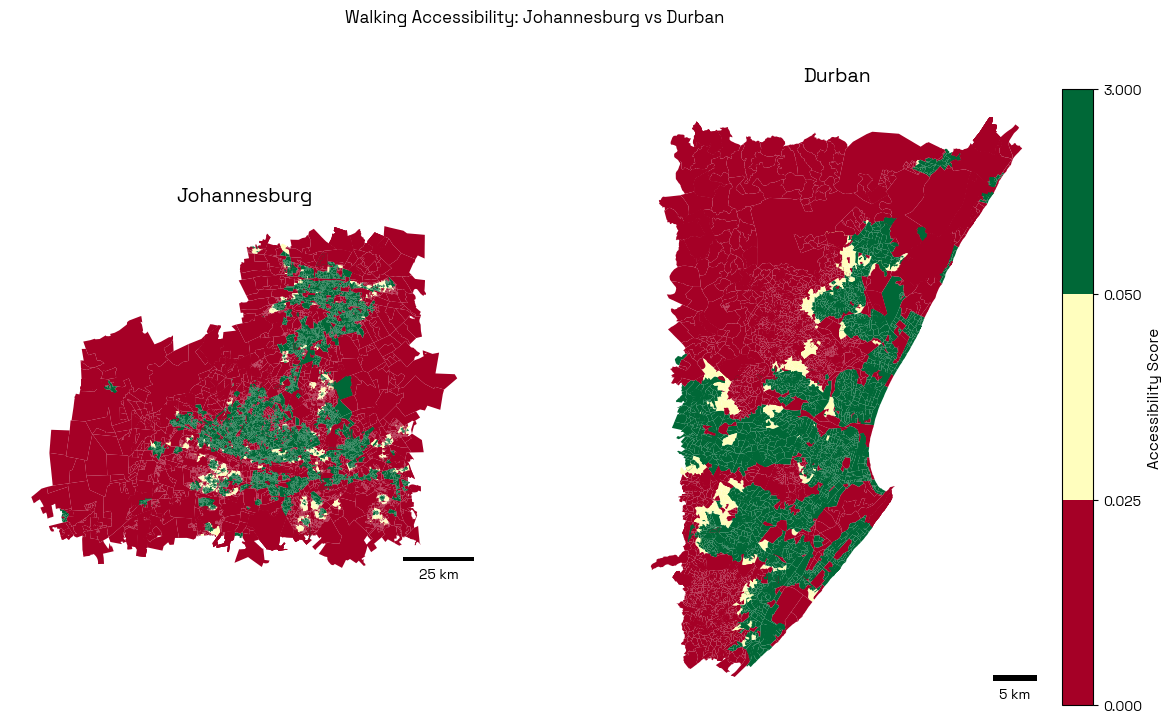

In [100]:
bin_edges = [0, 0.025, 0.05, 3]
cmap = mpl.cm.RdYlGn
norm = mpl.colors.BoundaryNorm(bin_edges, cmap.N)

fig, axes = plt.subplots(1, 2, figsize = (14, 8))
cities = {
    "Johannesburg": (3050000, 3170000, -3050000, -2950000),
    "Durban": (3434000, 3480000, -3506000, -3448000)
}

for i, (name, (xmin, xmax, ymin, ymax)) in enumerate(cities.items()):
    gdf = allaccess.cx[xmin:xmax, ymin:ymax]
    gdf.plot(column = "walk_log", cmap = cmap, norm = norm, ax = axes[i], edgecolor = "none")
    axes[i].set_title(name)
    axes[i].axis("off")
    scalebar = ScaleBar(dx = 1, units = "m", dimension = "si-length", location = "lower right")
    axes[i].add_artist(scalebar)

sm = mpl.cm.ScalarMappable(norm = norm, cmap = cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax = axes, fraction = 0.03, pad = 0.02)
cbar.set_label("Accessibility Score")
plt.suptitle("Walking Accessibility: Johannesburg vs Durban")
plt.show()

### Bottom/Top 10 SAL Highlight Maps

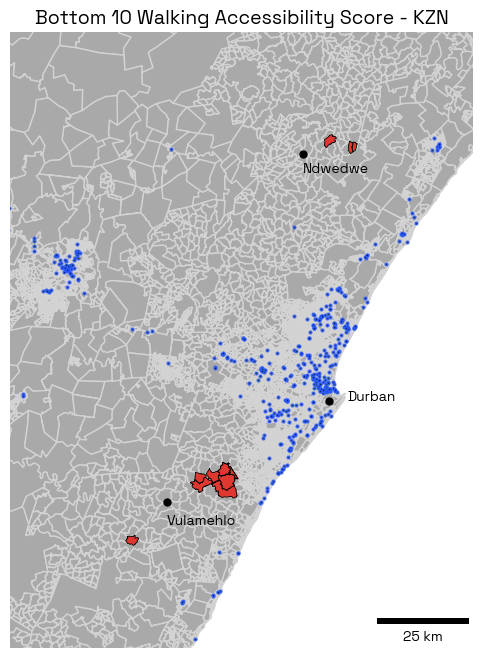

In [101]:
highlight_codes = [56010074, 54610011, 54610001, 54610002, 56010140,
                   56010136, 56010131, 56010138, 56010134, 56010137]

fig, ax = plt.subplots(figsize = (8, 8))
gdf_prov = allaccess[allaccess["PR_NAME"] == "KwaZulu-Natal"]
subset = gdf_prov[gdf_prov["EA_CODE"].isin(highlight_codes)]

gdf_prov.plot(ax = ax, color = "darkgrey", edgecolor = "lightgrey")
subset.plot(ax = ax, color = "#DE3831", linewidth = 0.6, edgecolor = "black")
pharm_with_sal.plot(ax = ax, color = "#001147", markersize = 4, alpha = 0.8, edgecolor = "#2E5FFF")

ax.scatter(3453460, -3488260, color = "black", s = 25, zorder = 20)
ax.text(3453460 + 5000, -3488260, "Durban", fontsize = 10, ha = "left")
ax.scatter(3446500, -3421000, color = "black", s = 25, zorder = 20)
ax.text(3446500, -3421000 - 5000, "Ndwedwe", fontsize = 10)
ax.scatter(3409300, -3516000, color = "black", s = 25, zorder = 20)
ax.text(3409300, -3516000 - 6000, "Vulamehlo", fontsize = 10)

minx, miny, maxx, maxy = subset.total_bounds
pad_x = (maxx - minx) * 0.5
pad_y = (maxy - miny) * 0.25
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
scalebar = ScaleBar(dx = 1, units = "m", dimension = "si-length", location = "lower right")
ax.add_artist(scalebar)
ax.set_title("Bottom 10 Walking Accessibility Score - KZN")
ax.axis("off")
plt.show()

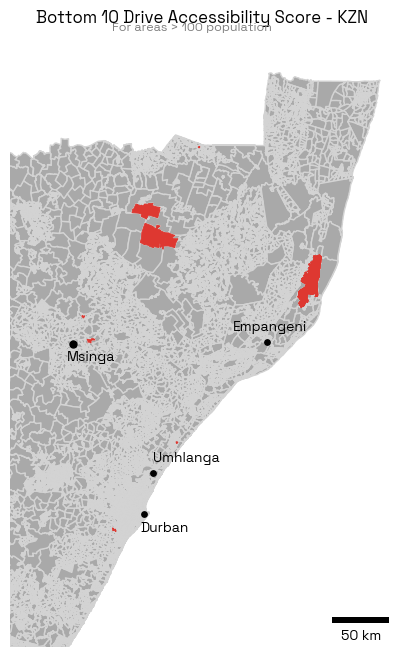

In [102]:
highlight_codes = [52910145, 52910137, 59210304, 58610076, 52910134,
                   57910165, 57610118, 59210227, 59910273, 57610147]

fig, ax = plt.subplots(figsize = (8, 8))
gdf_prov = allaccess[allaccess["PR_NAME"] == "KwaZulu-Natal"]
subset = gdf_prov[gdf_prov["EA_CODE"].isin(highlight_codes)]

gdf_prov.plot(ax = ax, color = "darkgrey", edgecolor = "lightgrey")
subset.plot(ax = ax, color = "#DE3831", linewidth = 0.6, edgecolor = "#DE3831")

durban_x, durban_y = 3453460, -3488260
ax.scatter(durban_x, durban_y, color = "black", s = 15, zorder = 20)
ax.text(durban_x - 3000, durban_y - 15000, "Durban", fontsize = 10)
ax.scatter(3461500, -3452000, color = "black", s = 15, zorder = 20)
ax.text(3461500, -3442000, "Umhlanga", fontsize = 10)
ax.scatter(3562000, -3336000, color = "black", s = 15, zorder = 20)
ax.text(3562000 - 30000, -3336000 + 10000, "Empangeni", fontsize = 10)
ax.scatter(3391030, -3337800, color = "black", s = 25, zorder = 20)
ax.text(3391030 - 5000, -3337800 - 15000, "Msinga", fontsize = 10, ha = "left")

minx, miny, maxx, maxy = subset.total_bounds
minx = min(minx, durban_x)
maxx = max(maxx, durban_x)
miny = min(miny, durban_y)
maxy = max(maxy, durban_y)
pad_x = (maxx - minx) * 0.3
pad_y = (maxy - miny) * 0.3
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
scalebar = ScaleBar(dx = 1, units = "m", location = "lower right")
ax.add_artist(scalebar)
ax.set_title("Bottom 10 Drive Accessibility Score - KZN", fontsize = 12)
fig.text(0.5, 0.88, "For areas > 100 population", ha = "center", fontsize = 9, color = "gray")
ax.axis("off")
plt.show()

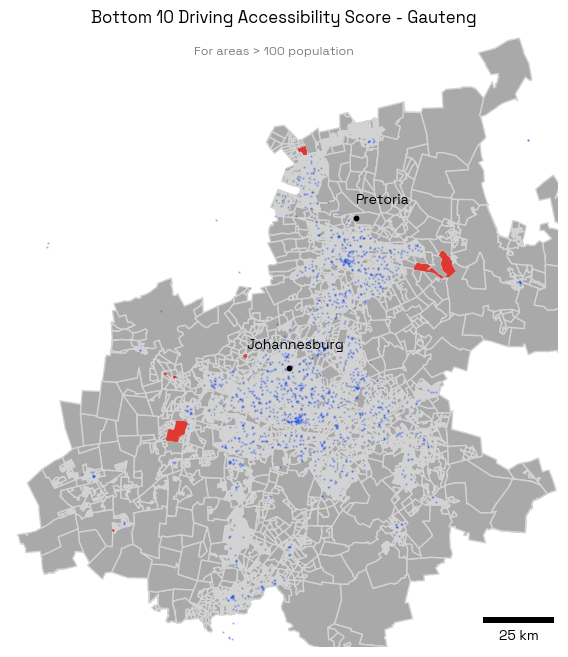

In [103]:
highlight_codes = [76310653, 79911566, 79914587, 76310630, 76410007,
                   79914588, 76310565, 76610048, 76610029, 79910975]

fig, ax = plt.subplots(figsize = (8, 8))
gdf_prov = allaccess[allaccess["PR_NAME"] == "Gauteng"]
subset = gdf_prov[gdf_prov["EA_CODE"].isin(highlight_codes)]

gdf_prov.plot(ax = ax, color = "darkgrey", edgecolor = "lightgrey")
subset.plot(ax = ax, color = "#DE3831", linewidth = 0.6, edgecolor = "#DE3831")
pharm_with_sal.plot(ax = ax, color = "#001147", markersize = 0.75, alpha = 0.25, edgecolor = "#2E5FFF")

ax.scatter(3118870, -3005460, color = "black", s = 10, zorder = 20)
ax.text(3118870 - 15000, -3005460 + 7000, "Johannesburg", fontsize = 10, ha = "left")
ax.scatter(3142400, -2952500, color = "black", s = 10, zorder = 20)
ax.text(3142400, -2952500 + 5000, "Pretoria", fontsize = 10)

minx, miny, maxx, maxy = subset.total_bounds
pad_x = (maxx - minx) * 0.3
pad_y = (maxy - miny) * 0.3
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
scalebar = ScaleBar(dx = 1, units = "m", location = "lower right")
ax.add_artist(scalebar)
ax.set_title("Bottom 10 Driving Accessibility Score - Gauteng", fontsize = 12)
fig.text(0.5, 0.85, "For areas > 100 population", ha = "center", fontsize = 9, color = "gray")
ax.axis("off")
plt.show()

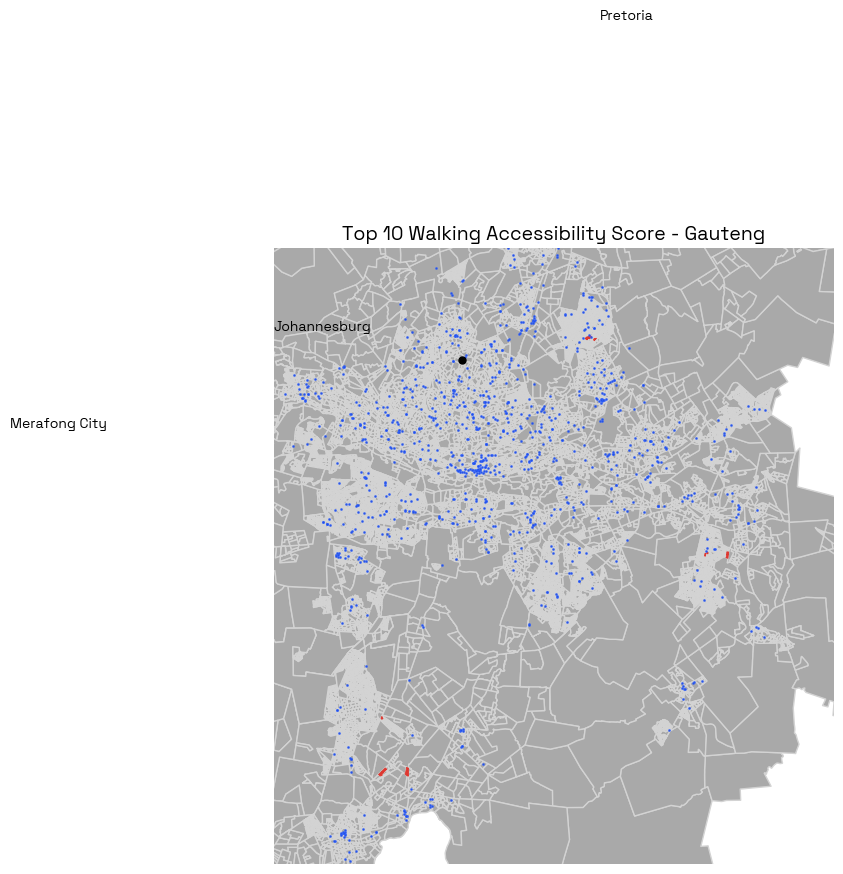

In [104]:
highlight_codes = [79712324, 79712083, 76011251, 79710301, 79715028,
                   76010707, 76010705, 76010586, 79714933, 79710300]

fig, ax = plt.subplots(figsize = (8, 8))
gdf_prov = allaccess[allaccess["PR_NAME"] == "Gauteng"]
subset = gdf_prov[gdf_prov["EA_CODE"].isin(highlight_codes)]

gdf_prov.plot(ax = ax, color = "darkgrey", edgecolor = "lightgrey")
subset.plot(ax = ax, color = "#DE3831", linewidth = 0.6, edgecolor = "#DE3831")
pharm_with_sal.plot(ax = ax, color = "#001147", markersize = 1, alpha = 0.8, edgecolor = "#2E5FFF")

ax.scatter(3118870, -3005460, color = "black", s = 25, zorder = 20)
ax.text(3118870 - 32000, -3005460 + 5000, "Johannesburg", fontsize = 10, ha = "left")
ax.scatter(3142400, -2952500, color = "black", s = 25, zorder = 20)
ax.text(3142400, -2952500 + 5000, "Pretoria", fontsize = 10)
ax.scatter(3049000, -3024000, color = "black", s = 25, zorder = 20)
ax.text(3049000 - 7000, -3024000 + 7000, "Merafong City", fontsize = 10)

minx, miny, maxx, maxy = subset.total_bounds
pad_x = (maxx - minx) * 0.3
pad_y = (maxy - miny) * 0.2
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.set_title("Top 10 Walking Accessibility Score - Gauteng")
ax.axis("off")
plt.show()

### Bivariate Map: Walking vs Driving Accessibility

Each SAL is classified into a 3x3 grid based on terciles of log-transformed
walk and drive scores. Grey = low/low (most underserved), blue = high/high
(best served). Insets zoom into Johannesburg/Pretoria and Durban.

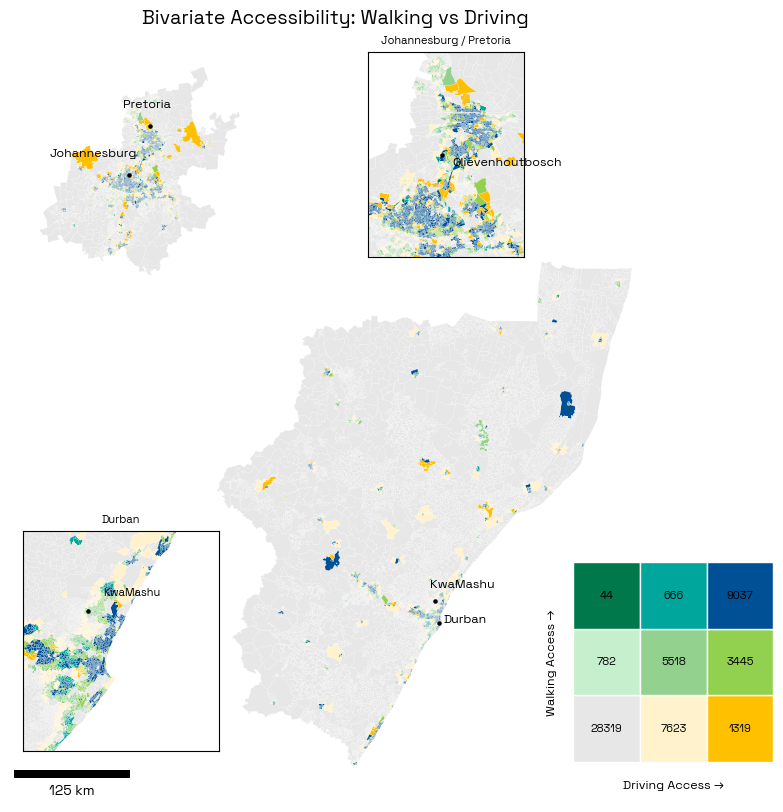

In [105]:
allaccess = allaccess.to_crs("EPSG:3857")

allaccess["walk_q"] = 0
mask = allaccess["walk_log"] > 0
allaccess.loc[mask, "walk_q"] = pd.qcut(allaccess.loc[mask, "walk_log"], 3, labels = [0, 1, 2])

allaccess["drive_q"] = 0
mask = allaccess["drive_log"] > 0
allaccess.loc[mask, "drive_q"] = pd.qcut(allaccess.loc[mask, "drive_log"], 3, labels = [0, 1, 2])

biv_colors = {
    (0, 0): "#E7E7E7",
    (0, 1): "#FFF2CC", (0, 2): "#FFC000",
    (1, 0): "#C6EFCE", (1, 1): "#92D18E", (1, 2): "#92D050",
    (2, 0): "#00784B", (2, 1): "#00A69B", (2, 2): "#005096"
}

allaccess["biv_color"] = allaccess.apply(
    lambda r: biv_colors[(int(r["walk_q"]), int(r["drive_q"]))], axis = 1
)
counts = pd.crosstab(allaccess["walk_q"], allaccess["drive_q"])

fig, ax = plt.subplots(figsize = (10, 10))
allaccess.plot(color = allaccess["biv_color"], ax = ax, linewidth = 0.1, edgecolor = "white")

ax.scatter(3118870, -3005460, color = "black", s = 5, zorder = 20)
ax.text(3118870 - 85000, -3005460 + 20000, "Johannesburg", fontsize = 9, ha = "left")
ax.scatter(3142400, -2952500, color = "black", s = 5, zorder = 20)
ax.text(3142400 - 30000, -2952500 + 20000, "Pretoria", fontsize = 9)
ax.scatter(3453460, -3488260, color = "black", s = 5, zorder = 20)
ax.text(3453460 + 5000, -3488260, "Durban", fontsize = 9, ha = "left")
ax.scatter(3449000, -3465000, color = "black", s = 5, zorder = 20)
ax.text(3449000 - 5000, -3465000 + 15000, "KwaMashu", fontsize = 9, ha = "left")

ax.set_title("Bivariate Accessibility: Walking vs Driving", fontsize = 14)
ax.axis("off")
scalebar = ScaleBar(dx = 1, units = "m", dimension = "si-length", location = "lower left")
ax.add_artist(scalebar)

# Legend grid.
legend_ax = fig.add_axes([0.75, 0.15, 0.2, 0.2])
legend_ax.axis("off")
for i in range(3):
    for j in range(3):
        rect = mpatches.Rectangle((j, i), 1, 1, facecolor = biv_colors[(i, j)], edgecolor = "white")
        legend_ax.add_patch(rect)
        value = counts.loc[i, j] if (i in counts.index and j in counts.columns) else 0
        legend_ax.text(j + 0.5, i + 0.5, f"{value}", ha = "center", va = "center", fontsize = 8)
legend_ax.set_xlim(0, 3)
legend_ax.set_ylim(0, 3)
legend_ax.text(1.5, -0.4, "Driving Access \u2192", ha = "center", fontsize = 9)
legend_ax.text(-0.4, 1.5, "Walking Access \u2192", va = "center", rotation = 90, fontsize = 9)

# Inset: Johannesburg.
axins = inset_axes(ax, width = "30%", height = "30%", bbox_to_anchor = (0, 0, 0.8, 1),
                   loc = "upper right", bbox_transform = ax.transAxes)
allaccess.plot(color = allaccess["biv_color"], ax = axins, linewidth = 0.1, edgecolor = "white")
axins.set_xlim(3090000, 3170000)
axins.set_ylim(-3035000, -2930000)
axins.scatter(3128000, -2983000, color = "black", s = 5, zorder = 20)
axins.text(3128000 + 5000, -2983000 - 5000, "Olievenhoutbosch", fontsize = 9, ha = "left")
axins.set_xticks([])
axins.set_yticks([])
axins.set_title("Johannesburg / Pretoria", fontsize = 8)

# Inset: Durban.
axins2 = inset_axes(ax, width = "30%", height = "30%", loc = "lower left",
                    bbox_to_anchor = (0.01, 0.05, 1, 1), bbox_transform = ax.transAxes)
allaccess.plot(color = allaccess["biv_color"], ax = axins2, linewidth = 0.1, edgecolor = "white")
axins2.set_xlim(3428000, 3492000)
axins2.set_ylim(-3511000, -3439000)
axins2.scatter(3449000, -3465000, color = "black", s = 5, zorder = 20)
axins2.text(3449000 + 5000, -3465000 + 5000, "KwaMashu", fontsize = 8, ha = "left")
axins2.set_xticks([])
axins2.set_yticks([])
axins2.set_title("Durban", fontsize = 8)

plt.show()